# WEEK-2 Graded Assignment: Linear Regression

## Introduction

In this exercise, you will implement linear regression and get to see it work on data. Before starting on this programming exercise, we strongly recommend watching the video lectures and work out ungraded assisgnment ,completing the review questions for the associated topics.

All the information you need for solving this assignment is in this notebook, and all the code you will be implementing will take place within this notebook.

Before we begin with the exercises, we need to import all libraries required for this programming exercise. Throughout the course, we will be using [`numpy`](http://www.numpy.org/) for all arrays and matrix operations, and [`matplotlib`](https://matplotlib.org/) for plotting.

In [66]:
# used for manipulating directory paths
import os

# Scientific and vector computation for python
import numpy as np

# Plotting library
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # needed to plot 3-D surfaces

# tells matplotlib to embed plots within the notebook
%matplotlib inline

Iris species of a flower is one of the most popular datasets for machine learning. This dataset is primarily for classification, but here we will use same dataset with some changes so that we can use it for Linear Regression. Let's load the dataset first.

In [67]:
import pandas as pd
from sklearn import datasets
iris = datasets.load_iris()

It includes three iris species named as 'setosa' , 'versicolor', 'virginica' with  some properties about each flower. One flower species is linearly separable from the other two, but the other two are not linearly separable from each other.

The columns in this dataset are:

Id,
Sepal Length Cm,
Sepal Width Cm,,
Petal Length Cm,
Petal Width Cm,
Species. Let's see some of the first rows of the datasets after loading it from sklearn.

In [68]:
iris_data =pd.DataFrame(iris.data, columns=iris.feature_names)
iris_data["target"]=iris.target
iris_data.head(20)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
6,4.6,3.4,1.4,0.3,0
7,5.0,3.4,1.5,0.2,0
8,4.4,2.9,1.4,0.2,0
9,4.9,3.1,1.5,0.1,0


We can now rename column name to make it more standard for ease of coding and readability.

In [69]:
iris_data.rename(columns={'sepal length (cm)':'sepal_length',
                          'sepal width (cm)':'sepal_width',
                          'petal length (cm)':'petal_length',
                          'petal width (cm)':'petal_width'},inplace=True)

Add a new column named "species" having value {if target == 0 : 'setosa' ,
if target ==1 : 'versicolor',
if target == 2 : 'virginica' }

In [70]:
iris_data["species"] = iris_data["target"].map({0:"setosa",1:"versicolor",2:"virginica"})
iris_data.head()


,sepal_length,sepal_width,petal_length,petal_width,target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


we will now select "versicolor" to predict its "petal_width" using "petal_length " as one of the parameter.So your next task is to make a new DataFrame named "data" having only rows whose species values are 'versicolor'.


In [71]:
data = iris_data[iris_data["species"] == "versicolor"]
data.head()

,sepal_length,sepal_width,petal_length,petal_width,target,species
50,7.0,3.2,4.7,1.4,1,versicolor
51,6.4,3.2,4.5,1.5,1,versicolor
52,6.9,3.1,4.9,1.5,1,versicolor
53,5.5,2.3,4.0,1.3,1,versicolor
54,6.5,2.8,4.6,1.5,1,versicolor


Now we are droping  all the columns except petal_length and petal_width

In [72]:
data.drop(columns=['target','species','sepal_length','sepal_width'],inplace=True)
data.head()

C:\Users\tiwar_z5dvqky\AppData\Local\Temp\ipykernel_9908\220937503.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop(columns=['target','species','sepal_length','sepal_width'],inplace=True)


,petal_length,petal_width
50,4.7,1.4
51,4.5,1.5
52,4.9,1.5
53,4.0,1.3
54,4.6,1.5


Now write code to print the shape of DataFrame named as data.

In [73]:
print("Shape of the data = ",data.shape)

Shape of the data =  (50, 2)


Now  plot the Dataframe named data having x axis as 'petal_length', y axis as 'petal_width' and kind='scatter'

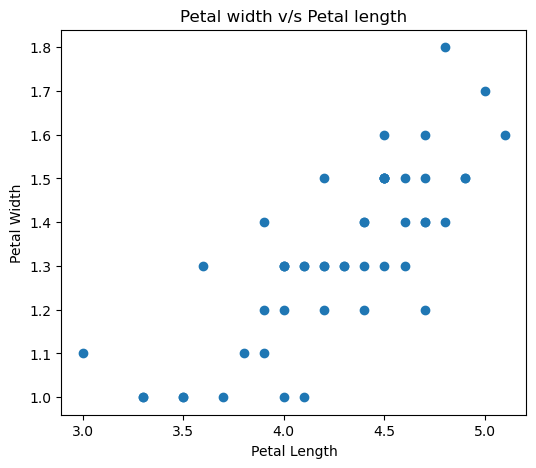

In [74]:
fig,ax = plt.subplots(1,1,figsize=(6,5))
ax.scatter(data["petal_length"],data["petal_width"])
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Petal width v/s Petal length")
plt.show()

**The graph plotted above surely has a positive correlation between Petal width and Petal length meaning as Petal length increase so is Petal width. Since the data follow a linear pattern, Linear Regression can be used effectively here to predict data.**

Now let's start with Linear Regression

We will now split the dataset into training and test datasets into (X_train,Y_train) and (X_test,Y_test)

In [75]:
from sklearn.model_selection import train_test_split
X=data['petal_length'].values.reshape(-1,1)
Y=data['petal_width'].values.reshape(-1,1)
X_train,X_test,Y_train,Y_test=train_test_split(X,Y, test_size=0.33,random_state=1)


Now let's plot the training  datasets of  kind scatter with x axis as X_train and y axis as Y_train.

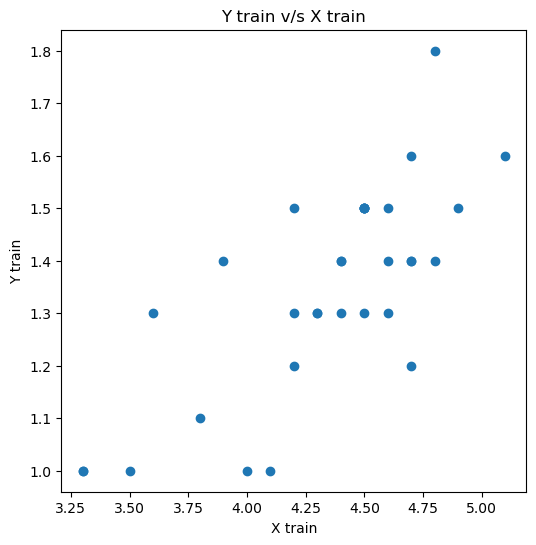

In [76]:
fig,ax = plt.subplots(1,1,figsize=(6,6))
ax.scatter(X_train,Y_train)
plt.xlabel("X train")
plt.ylabel("Y train")
plt.title("Y train v/s X train")
plt.show()

Now let's plot the test datasets of kind scatter with x axis as X_test and y axis as Y_test

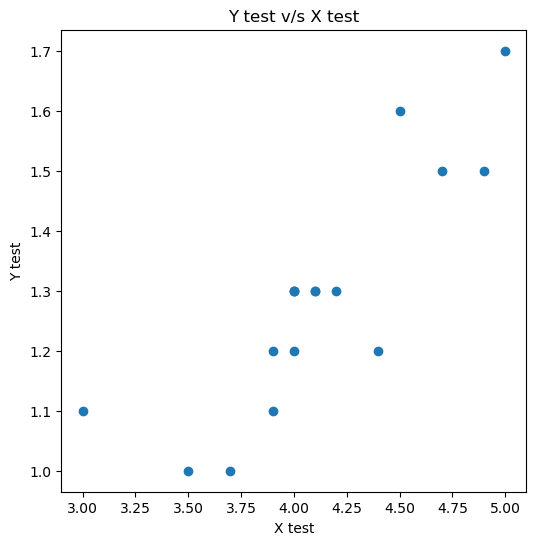

In [77]:
fig,ax = plt.subplots(1,1,figsize=(6,6))
ax.scatter(X_test,Y_test)
plt.xlabel("X test")
plt.ylabel("Y test")
plt.title("Y test v/s X test")
plt.show()

Now write the code for LinearRegession using any preffered method.

In [78]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Now print the Intercept and Coefficient.

In [79]:
m = lr.coef_
b = lr.intercept_
print("Coefficient found using Linear Regression =",float(m))
print("Intercept found using Linear Regression =",float(b))

Coefficient found using Linear Regression = 0.3338593974175036
Intercept found using Linear Regression = -0.10228120516499262


C:\Users\tiwar_z5dvqky\AppData\Local\Temp\ipykernel_9908\2638376186.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("Coefficient found using Linear Regression =",float(m))
C:\Users\tiwar_z5dvqky\AppData\Local\Temp\ipykernel_9908\2638376186.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("Intercept found using Linear Regression =",float(b))


Now we can overlay the predicted line and test data points to see where the predicted point lies.

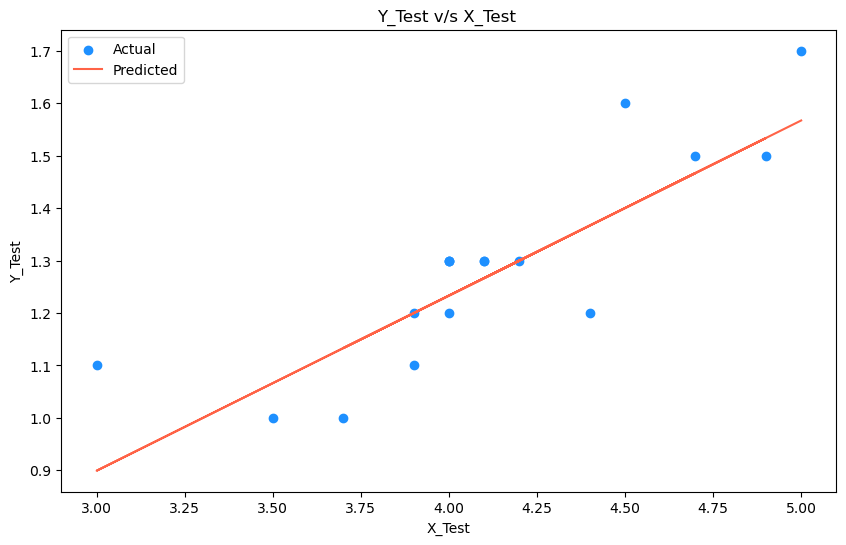

Score of Linear Regression Model =  0.7138793935182639


In [80]:
fig,ax = plt.subplots(1,1,figsize=(10,6))
ax.scatter(X_test,Y_test,marker='o',c='dodgerblue',label='Actual')
plt.xlabel("X_Test")
plt.ylabel("Y_Test")
plt.title("Y_Test v/s X_Test ")
ax.plot(X_test,((m*X_test)+b),c="tomato",label = 'Predicted')
plt.legend()
plt.show()
print("Score of Linear Regression Model = ",lr.score(X_test,Y_test))

**The above graph displays the comparison between the predicted line(red line) and the actual data points. This Linear Regression Model finds the Coefficient and Intercept using the Training data and predicts the test data. It finds the best fit straight line(red line) with the above mentioned score for the given data which minimizes the cost function as much as possible.**

### Lasso Regression

Let's implement Lasso Regression, which is a type of linear regression that uses shrinkage. Shrinkage is where data values are shrunk towards a central point as the mean. The Lasso method encourages simple models (i.e., models with fewer parameters), in some cases completely eliminating the effect of some features. It's often used for feature selection and to prevent overfitting.

In [81]:
# Import Lasso from sklearn
# Create a Lasso regressor object with an alpha (regularization strength) value
# Fit the model to the training data
#your code here
from sklearn.linear_model import Lasso
ls = Lasso(alpha = 0.002)
ls.fit(X_train,Y_train)



,alpha,0.002
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [82]:
# Print the Intercept and Coefficient for Lasso Regression
#your code here
m1 = ls.coef_
b1 = ls.intercept_
print("Intercept using Lasso Regression = ",float(ls.intercept_))
print("Coefficient using Lasso Regression = ",float(ls.coef_))

Intercept using Lasso Regression =  -0.05711334289813497
Coefficient using Lasso Regression =  0.3234433285509326


C:\Users\tiwar_z5dvqky\AppData\Local\Temp\ipykernel_9908\994811847.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("Intercept using Lasso Regression = ",float(ls.intercept_))
C:\Users\tiwar_z5dvqky\AppData\Local\Temp\ipykernel_9908\994811847.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("Coefficient using Lasso Regression = ",float(ls.coef_))


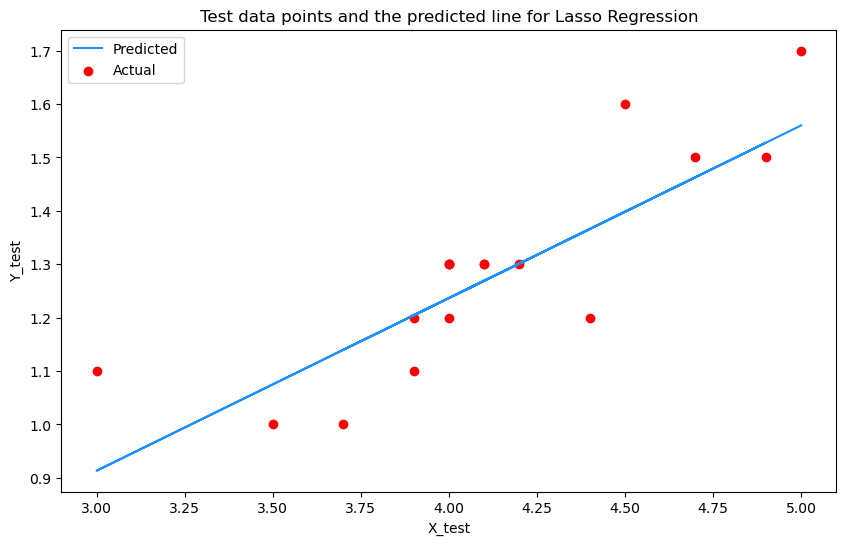

score of a linear regression model =  0.7138793935182639
score of a lasso regression model =  0.7148423921335337


In [83]:
# Predict on the test data
# Plot the test data points and the predicted line for Lasso Regression
#your code here
fig,ax = plt.subplots(1,1,figsize=(10,6))
ax.plot(X_test,((m1*X_test) + b1),c='dodgerblue',label = 'Predicted')
ax.scatter(X_test,Y_test,c='r',label='Actual')
plt.xlabel("X_test")
plt.ylabel("Y_test")
plt.title("Test data points and the predicted line for Lasso Regression")
plt.legend()
plt.show()
print("score of a linear regression model = ",lr.score(X_test,Y_test))
print("score of a lasso regression model = ",ls.score(X_test,Y_test))

**Lasso Regression a L1 type regularization technique used to correct the model which is overfit and which is not generalized to predict other data. In this case our linear regression model works well so lasso regression model doesn't make much difference as we can see the scores of both models above, score of lasso regression model is very slightly higher than the linear regression model.**

### Ridge Regression

Next, let's explore Ridge Regression. Like Lasso, Ridge Regression is also a regularization technique used to prevent overfitting, but it penalizes the sum of the squares of the coefficients. This tends to shrink the coefficients towards zero but doesn't set them exactly to zero, meaning it keeps all features in the model, unlike Lasso which can perform feature selection.

In [84]:
# Import Ridge from sklearn
# Create a Ridge regressor object with an alpha (regularization strength) value
# Fit the model to the training data
#your code here
from sklearn.linear_model import Ridge
rd = Ridge(alpha = 0.2)
rd.fit(X_train,Y_train)

,alpha,0.2
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [85]:
# Print the Intercept and Coefficient for Ridge Regression
#your code here
m2 = rd.coef_
b2 = rd.intercept_
print("Coefficient using Ridge Regression= ",float(m2))
print("Intercept using Ridge Regression = ",float(b2))

Coefficient using Ridge Regression=  0.323643949930459
Intercept using Ridge Regression =  -0.057983310152990075


C:\Users\tiwar_z5dvqky\AppData\Local\Temp\ipykernel_9908\261904825.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("Coefficient using Ridge Regression= ",float(m2))
C:\Users\tiwar_z5dvqky\AppData\Local\Temp\ipykernel_9908\261904825.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("Intercept using Ridge Regression = ",float(b2))


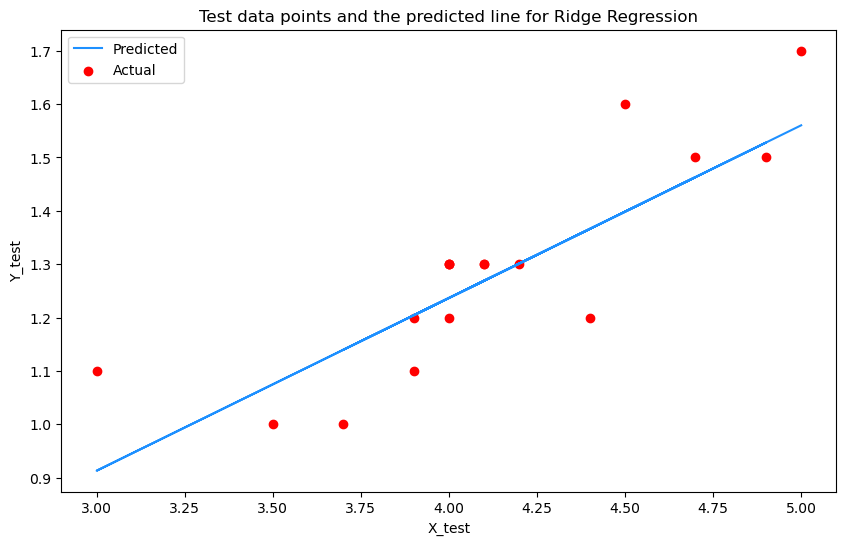

score of a linear regression model =  0.7138793935182639
score of a ridge regression model =  0.7148396888371702


In [86]:
# Predict on the test data
# Plot the test data points and the predicted line for Ridge Regression
#your code here
fig,ax = plt.subplots(1,1,figsize=(10,6))
ax.plot(X_test,((m2*X_test) + b2),c='dodgerblue',label = 'Predicted')
ax.scatter(X_test,Y_test,c='r',label='Actual')
plt.xlabel("X_test")
plt.ylabel("Y_test")
plt.title("Test data points and the predicted line for Ridge Regression")
plt.legend()
plt.show()
print("score of a linear regression model = ",lr.score(X_test,Y_test))
print("score of a ridge regression model = ",rd.score(X_test,Y_test))

**Ridge Regression a L2 type regularization technique used to correct the model which is overfit and which is not generalized to predict other data. In this case our linear regression model works well so ridge regression model doesn't make much difference as we can see the scores of both models above, score of ridge regression model is very slightly higher than the linear regression model.**

This is end of assisgnment , but for futhur reading you can search articles on Multivariate Regression , ElasticNet regression and Stepwise Regression.